In [1]:
# =========================================================
# [셀 1] 프로젝트 개요
# ---------------------------------------------------------
# 화성시 송산면 근린생활 프로젝트 PDF 자료들을 기반으로
# 건축 적산(Project-specific Cost Estimation) RAG 시스템 구축
#
# 주요 기능:
# 1. PDF 문서 로딩
# 2. 텍스트 추출 및 청크 분할
# 3. OpenAI Embedding 생성
# 4. ChromaDB 벡터 저장
# 5. Retriever 생성
# 6. 적산 질의응답 체인 구축
#
# 작업 디렉토리:
# D:\PyProject\AIFFEL_AI\LLM\Main_Quest\Agent
#
# PDF 경로:
# D:\PyProject\AIFFEL_AI\LLM\Main_Quest\data\arch_cost\
# 210111 화성시 송산면 근린생활
#
# .env 경로:
# D:\PyProject\env_keys\.env
# =========================================================

In [3]:
# =========================================================
# [셀 2] 필요한 라이브러리 설치
# ---------------------------------------------------------
# 최초 1회만 실행
# =========================================================

!pip install -U langchain
!pip install -U langchain-community
!pip install -U langchain-openai
!pip install -U chromadb
!pip install -U pypdf
!pip install -U python-dotenv
!pip install -U tiktoken


  Attempting uninstall: langgraph-checkpoint

    Found existing installation: langgraph-checkpoint 4.0.1

    Uninstalling langgraph-checkpoint-4.0.1:

      Successfully uninstalled langgraph-checkpoint-4.0.1

   ---------------------------------------- 0/4 [langgraph-checkpoint]
   ---------------------------------------- 0/4 [langgraph-checkpoint]
  Attempting uninstall: langgraph-prebuilt
   ---------------------------------------- 0/4 [langgraph-checkpoint]
    Found existing installation: langgraph-prebuilt 1.0.8
   ---------------------------------------- 0/4 [langgraph-checkpoint]
    Uninstalling langgraph-prebuilt-1.0.8:
   ---------------------------------------- 0/4 [langgraph-checkpoint]
   ---------- ----------------------------- 1/4 [langgraph-prebuilt]
      Successfully uninstalled langgraph-prebuilt-1.0.8
   ---------- ----------------------------- 1/4 [langgraph-prebuilt]
  Attempting uninstall: langgraph
   ---------- ----------------------------- 1/4 [langgraph-p

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.2.16 requires langchain<0.3.0,>=0.2.16, but you have langchain 1.3.0 which is incompatible.
langchain-community 0.2.16 requires langchain-core<0.3.0,>=0.2.38, but you have langchain-core 1.4.0 which is incompatible.
langchain-community 0.2.16 requires langsmith<0.2.0,>=0.1.0, but you have langsmith 0.8.3 which is incompatible.
langchain-experimental 0.4.1 requires langchain-community<1.0.0,>=0.4.0, but you have langchain-community 0.2.16 which is incompatible.


  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
Using cached langchain_community-0.4.1-py3-none-any.whl (2.5 MB)

  Attempting uninstall: langchain-text-splitters

    Found existing installation: langchain-text-splitters 0.2.4

    Uninstalling langchain-text-splitters-0.2.4:

      Successfully uninstalled langchain-text-splitters-0.2.4

   ---------------------------------------- 0/2 [langchain-text-splitters]
  Attempting uninstall: langchain-community
   ---------------------------------------- 0/2 [langchain-text-splitters]
    Found existing installation: langchain-community 0.2.16
   ---------------------------------------- 0/2 [langchain-text-splitters]
   -------------------- ------------------- 1/2 [langchain-community]
   -------------------- ------------------- 1/2 [langchain-community]
   -------------------- ------------------- 1/2 [langchain-community]
   -------------------- ------------------- 1/2 [langchain-community]
   ------------------

In [4]:
# =========================================================
# [셀 3] 기본 라이브러리 import 및 환경변수 로드
# ---------------------------------------------------------
# .env 파일에서 OpenAI / HuggingFace API Key 로드
# =========================================================

import os
from dotenv import load_dotenv

# .env 파일 경로
env_path = r"D:\PyProject\env_keys\.env"

# 환경변수 로드
load_dotenv(env_path)

# API KEY 확인
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")

print("OPENAI_API_KEY :", "Loaded" if OPENAI_API_KEY else "Not Found")
print("HF_TOKEN :", "Loaded" if HF_TOKEN else "Not Found")

OPENAI_API_KEY : Loaded
HF_TOKEN : Loaded


In [7]:
# =========================================================
# [셀 4] 프로젝트 경로 설정
# ---------------------------------------------------------
# PDF 원본 폴더 및 벡터DB 저장 폴더 설정
# =========================================================

from pathlib import Path

# PDF 폴더
PDF_DIR = Path(
    r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\data\arch_cost\210111 화성시 송산면 근린생활"
)

# 벡터DB 저장 경로
VECTOR_DB_DIR = Path(
    r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\Agent\vector_db\hwaseong_arch_cost"
)

# 생성
VECTOR_DB_DIR.mkdir(parents=True, exist_ok=True)

print("PDF_DIR :", PDF_DIR)
print("VECTOR_DB_DIR :", VECTOR_DB_DIR)

PDF_DIR : D:\PyProject\AIFFEL_AI\LLM\Main_Quest\data\arch_cost\210111 화성시 송산면 근린생활
VECTOR_DB_DIR : D:\PyProject\AIFFEL_AI\LLM\Main_Quest\Agent\vector_db\hwaseong_arch_cost


In [13]:
# =========================================================
# [셀 5] PDF 파일 목록 확인
# ---------------------------------------------------------
# 프로젝트 내 PDF 파일 개수 확인
# =========================================================

pdf_files = list(PDF_DIR.glob("*.pdf"))

print(f"총 PDF 개수 : {len(pdf_files)}")

for idx, pdf in enumerate(pdf_files):
    print(f"{idx+1}. {pdf.name}")

총 PDF 개수 : 16
1. 01 동개요.pdf
2. 03 동별 층리스트.pdf
3. 04 동별 창호리스트.pdf
4. 06 창호산출서.pdf
5. 07 내부산출서(일반동).pdf
6. 09 외부산출서.pdf
7. 12 철골산출서.pdf
8. 13 가설산출서.pdf
9. 15 공용산출서.pdf
10. 16 공종별집계표.pdf
11. 17 동별집계표.pdf
12. 19 일반동 층별집계표.pdf
13. 20 층별집계표.pdf
14. 21 실별(아파트)집계표.pdf
15. 22 실별(일반동)집계표.pdf
16. 25 부자재집계표.pdf


In [15]:
# =========================================================
# [셀 6] PDF 문서 로딩
# ---------------------------------------------------------
# 각 PDF를 읽어서 LangChain Document 형태로 로딩
# =========================================================

from langchain_community.document_loaders import PyPDFLoader

documents = []

for pdf_file in pdf_files:
    
    try:
        loader = PyPDFLoader(str(pdf_file))
        docs = loader.load()
        
        # 메타데이터 추가
        for doc in docs:
            doc.metadata["source_file"] = pdf_file.name
        
        documents.extend(docs)
        
        print(f"[완료] {pdf_file.name} -> {len(docs)} pages")
        
    except Exception as e:
        print(f"[에러] {pdf_file.name}")
        print(e)

print("\n총 Document 수 :", len(documents))

D:\anaconda3\envs\aiffel\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H 

[완료] 01 동개요.pdf -> 1 pages
[완료] 03 동별 층리스트.pdf -> 1 pages
[완료] 04 동별 창호리스트.pdf -> 1 pages
[완료] 06 창호산출서.pdf -> 1 pages
[완료] 07 내부산출서(일반동).pdf -> 1 pages
[완료] 09 외부산출서.pdf -> 1 pages
[완료] 12 철골산출서.pdf -> 1 pages
[완료] 13 가설산출서.pdf -> 1 pages
[완료] 15 공용산출서.pdf -> 2 pages
[완료] 16 공종별집계표.pdf -> 4 pages


Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet
Advanced encoding /KSCms-UHC-HW-H not implemented yet


[완료] 17 동별집계표.pdf -> 4 pages
[완료] 19 일반동 층별집계표.pdf -> 1 pages
[완료] 20 층별집계표.pdf -> 4 pages
[완료] 21 실별(아파트)집계표.pdf -> 1 pages
[완료] 22 실별(일반동)집계표.pdf -> 2 pages
[완료] 25 부자재집계표.pdf -> 1 pages

총 Document 수 : 27


In [22]:
# =========================================================
# [추가 셀] 실제 텍스트 품질 확인
# =========================================================

for i in range(min(5, len(documents))):

    print("\n" + "="*80)
    print(f"[문서 {i}]")
    print("="*80)

    print(documents[i].metadata)

    print("\n[텍스트 내용]\n")

    print(documents[i].page_content[:2000])


[문서 0]
{'producer': 'Fin(ver6.2)', 'creator': '°í·ÁÀü»ê(ÁÖ) www.koreasoft.co.kr', 'creationdate': 'D:20260321104316', 'source': 'D:\\PyProject\\AIFFEL_AI\\LLM\\Main_Quest\\data\\arch_cost\\210111 화성시 송산면 근린생활\\01 동개요.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'source_file': '01 동개요.pdf'}

[텍스트 내용]

Page   1
µ¿ °³ ¿ä
±¸ºÐ µ¿       ¸í ÁöÇÏÃþ¼ö Áö»óÃþ¼ö ¿ÁÅ¾Ãþ¼ö Æò ºñ        °í
°ø»ç¸í:210111 - È­¼º½Ã ¼Û»ê¸é ±Ù¸°»ýÈ°
¿¬¸éÀû
01.°øÀåÀÏ¹Ý 0.00010 0.0001

[문서 1]
{'producer': 'Fin(ver6.2)', 'creator': '°í·ÁÀü»ê(ÁÖ) www.koreasoft.co.kr', 'creationdate': 'D:20260321104316', 'source': 'D:\\PyProject\\AIFFEL_AI\\LLM\\Main_Quest\\data\\arch_cost\\210111 화성시 송산면 근린생활\\03 동별 층리스트.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'source_file': '03 동별 층리스트.pdf'}

[텍스트 내용]

°è F1 P1
01.°øÀåµ¿¸íÄª:]-[ È­¼º½Ã ¼Û»ê¸é ±Ù¸°»ýÈ°210111 Page   1
ÀÏ ¹Ý µ¿ Ãþ ¸® ½º Æ®
Ãþ ¸í
01. Áö»ó1Ãþ 1 1
02. ¿ÁÅ¾1Ãþ 1 1

[문서 2]
{'producer': 'Fin(ver6.2)', 'creator': '°í·ÁÀü»ê(ÁÖ) www.koreasoft.co.kr', 'creationd

In [24]:
!pip install pymupdf

In [26]:
# =========================================================
# [수정 셀] PyMuPDF 기반 PDF 로딩
# ---------------------------------------------------------
# 한글 PDF 인코딩 개선
# =========================================================

from langchain_community.document_loaders import PyMuPDFLoader

documents = []

for pdf_file in pdf_files:

    try:
        loader = PyMuPDFLoader(str(pdf_file))

        docs = loader.load()

        for doc in docs:
            doc.metadata["source_file"] = pdf_file.name

        documents.extend(docs)

        print(f"[완료] {pdf_file.name} -> {len(docs)} pages")

    except Exception as e:

        print(f"[에러] {pdf_file.name}")
        print(e)

print("\n총 Document 수 :", len(documents))

[완료] 01 동개요.pdf -> 1 pages
[완료] 03 동별 층리스트.pdf -> 1 pages
[완료] 04 동별 창호리스트.pdf -> 1 pages
[완료] 06 창호산출서.pdf -> 1 pages
[완료] 07 내부산출서(일반동).pdf -> 1 pages
[완료] 09 외부산출서.pdf -> 1 pages
[완료] 12 철골산출서.pdf -> 1 pages
[완료] 13 가설산출서.pdf -> 1 pages
[완료] 15 공용산출서.pdf -> 2 pages
[완료] 16 공종별집계표.pdf -> 4 pages
[완료] 17 동별집계표.pdf -> 4 pages
[완료] 19 일반동 층별집계표.pdf -> 1 pages
[완료] 20 층별집계표.pdf -> 4 pages
[완료] 21 실별(아파트)집계표.pdf -> 1 pages
[완료] 22 실별(일반동)집계표.pdf -> 2 pages
[완료] 25 부자재집계표.pdf -> 1 pages

총 Document 수 : 27


In [28]:
print(documents[0].page_content)

Page
   1
동 개 요
구분
동       명
지하층수
지상층수
옥탑층수
평
비        고
공사명: 210111  -  화성시 송산면 근린생활
연면적
01.공장
일반
0.000
1
0
0.000
1


In [30]:
# =========================================================
# [셀 7] 문서 샘플 확인
# ---------------------------------------------------------
# 로딩된 문서 일부 확인
# =========================================================

sample_doc = documents[0]

print(sample_doc.metadata)
print("\n")
print(sample_doc.page_content[:3000])

{'producer': 'Fin(ver6.2)', 'creator': '°í·ÁÀü»ê(ÁÖ) www.koreasoft.co.kr', 'creationdate': 'D:20260321104316', 'source': 'D:\\PyProject\\AIFFEL_AI\\LLM\\Main_Quest\\data\\arch_cost\\210111 화성시 송산면 근린생활\\01 동개요.pdf', 'file_path': 'D:\\PyProject\\AIFFEL_AI\\LLM\\Main_Quest\\data\\arch_cost\\210111 화성시 송산면 근린생활\\01 동개요.pdf', 'total_pages': 1, 'format': 'PDF 1.3', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': 'D:20260321104316', 'page': 0, 'source_file': '01 동개요.pdf'}


Page
   1
동 개 요
구분
동       명
지하층수
지상층수
옥탑층수
평
비        고
공사명: 210111  -  화성시 송산면 근린생활
연면적
01.공장
일반
0.000
1
0
0.000
1


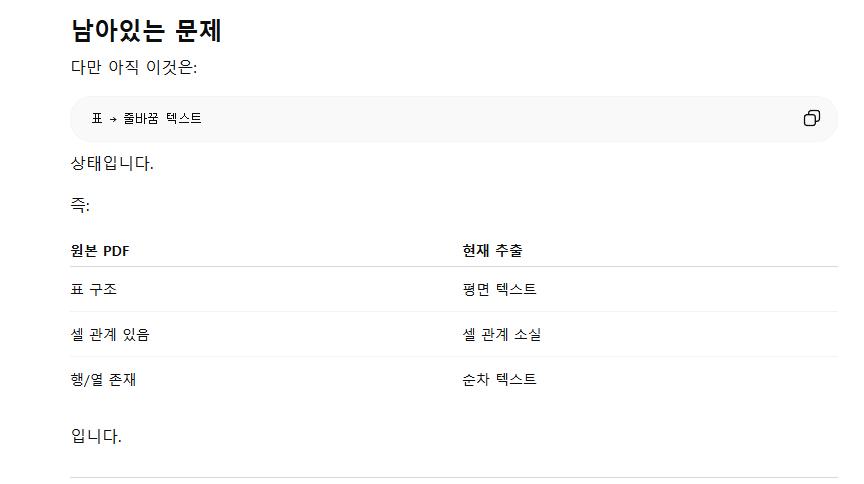

In [37]:
# !pip install -U langchain-text-splitters

# =========================================================
# [셀 8] 텍스트 청크 분할
# ---------------------------------------------------------
# 긴 문서를 RAG 검색용 Chunk로 분할
# =========================================================

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    separators=["\n\n", "\n", " ", ""]
)

split_docs = text_splitter.split_documents(documents)

print("원본 문서 수 :", len(documents))
print("청크 수 :", len(split_docs)) # 청크 사이즈 보다 작아서 청크 단위로 분할되지 않았음

원본 문서 수 : 27
청크 수 : 27


#### 청크 사이즈 보다 작아서 청크 단위로 분할되지 않았음
#### 추천 방식
- "페이지 단위 유지" 또는 "표 row 단위 chunk" 가 훨씬 좋습니다.

  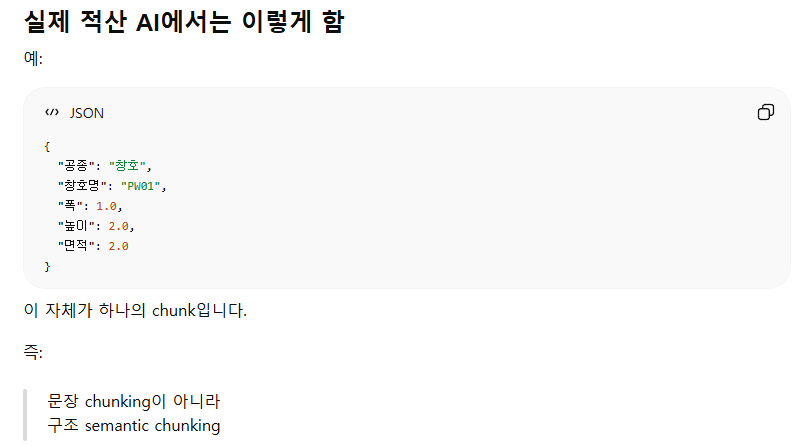

In [45]:
# =========================================================
# [셀 9] 청크 샘플 확인
# ---------------------------------------------------------
# 실제 분할된 Chunk 확인
# =========================================================

print(split_docs[0].metadata)

print("\n========================\n")

print(split_docs[0].page_content)

{'producer': 'Fin(ver6.2)', 'creator': '°í·ÁÀü»ê(ÁÖ) www.koreasoft.co.kr', 'creationdate': 'D:20260321104316', 'source': 'D:\\PyProject\\AIFFEL_AI\\LLM\\Main_Quest\\data\\arch_cost\\210111 화성시 송산면 근린생활\\01 동개요.pdf', 'file_path': 'D:\\PyProject\\AIFFEL_AI\\LLM\\Main_Quest\\data\\arch_cost\\210111 화성시 송산면 근린생활\\01 동개요.pdf', 'total_pages': 1, 'format': 'PDF 1.3', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': 'D:20260321104316', 'page': 0, 'source_file': '01 동개요.pdf'}


Page
   1
동 개 요
구분
동       명
지하층수
지상층수
옥탑층수
평
비        고
공사명: 210111  -  화성시 송산면 근린생활
연면적
01.공장
일반
0.000
1
0
0.000
1


In [47]:
# =========================================================
# [셀 10] OpenAI Embedding 모델 로드
# ---------------------------------------------------------
# text-embedding-3-large 사용
# 건축 적산 문서 검색 품질 향상
# =========================================================

from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

print("Embedding Model Ready")

Embedding Model Ready


In [49]:
# =========================================================
# [셀 11] ChromaDB 벡터DB 생성
# ---------------------------------------------------------
# PDF 청크들을 임베딩하여 Vector DB 생성
# =========================================================

from langchain_community.vectorstores import Chroma

vector_db = Chroma.from_documents(
    documents=split_docs,
    embedding=embedding_model,
    persist_directory=str(VECTOR_DB_DIR)
)

print("Vector DB 생성 완료")

Vector DB 생성 완료


In [51]:
# =========================================================
# [셀 12] Vector DB 저장
# ---------------------------------------------------------
# 디스크에 영구 저장
# =========================================================

vector_db.persist()

print("Vector DB 저장 완료")
print(VECTOR_DB_DIR)

Vector DB 저장 완료
D:\PyProject\AIFFEL_AI\LLM\Main_Quest\Agent\vector_db\hwaseong_arch_cost


C:\Users\hugctx\AppData\Local\Temp\ipykernel_28008\2342621712.py:7: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vector_db.persist()


In [53]:
# =========================================================
# [셀 13] Retriever 생성
# ---------------------------------------------------------
# 적산 관련 검색 성능 향상을 위한 Retriever 구성
# =========================================================

retriever = vector_db.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 5
    }
)

print("Retriever Ready")

Retriever Ready


In [55]:
# =========================================================
# [셀 14] 검색 테스트
# ---------------------------------------------------------
# 실제 적산 질의 테스트
# =========================================================

query = "철근 물량 산출 기준"

results = retriever.invoke(query)

print(f"검색 결과 개수 : {len(results)}")

for idx, doc in enumerate(results):
    
    print(f"\n================ RESULT {idx+1} ================\n")
    
    print("파일 :", doc.metadata.get("source_file"))
    print(doc.page_content[:1500])

검색 결과 개수 : 5

================ RESULT 1 ================

파일 : 16 공종별집계표.pdf
210111  -  화성시 송산면 근린생활
물량(할증포함)
동명: 01.공장(일반)
   1 Page
공사명:
할증(%)
비             고
물  량
규      격
코 드
단위
품      명
공 종 별 집 계 표
철근콘크리트공사
04
D350/400), HD-13, 하치장상차도
TON
철근콘크리트용봉강, 이형봉강(S
철근콘크리트용봉강
3010161920161124
0.0
2.484
2.484
TON
보통(미할증) - 18-2/4 삭제
현장 철근 가공 및 조립
ADB000130000
0.0
2.484
2.484
M3
버림
무근콘크리트 타설
ADF102700100
0.0
3.549
3.549
)
미만, 붐타설 - 17년1분기삭제
M3
슬럼프=8∼12, 1일 타설량=50m3
철근콘크리트 타설 / 펌프차(21m
ADF202100100
0.0
31.959
31.959
㎥
25-240-15
레미콘(철근)
ZR000000001
0.0
31.959
31.959
M3
잡석
잡
ZR000000002
0.0
14.196
14.196
㎥
40-135-8
레미콘(무근)
ZR000000003
0.0
2.337
2.337
㎡
유로폼
거푸집
ZR000000006
0.0
72.000
72.000
철  골  공  사
05
착도
TON
SS275, 200*100*5.5*8mm, 현장도
H형강
3010170411000007
7.0
0.911
0.852
21.3kg/m
착도
TON
SS275, 200*200*8*12mm, 현장도
H형강
3010170411000009
7.0
4.110
3.842
49.9kg/m
도
TON
SS275, 250*125*6*9mm, 현장도착
H형강
3010170411000014
7.0
0.594
0.556
29.6kg/m
착도
TON
SS275, 350*175*7*11mm, 현장도
H형강
3010170411000033
7.

In [57]:
# =========================================================
# [셀 15] LLM 로드
# ---------------------------------------------------------
# GPT-4.1-mini 기반 적산 QA 모델
# =========================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

print("LLM Ready")

LLM Ready


In [61]:
# =========================================================
# [셀 16] RAG Prompt 생성
# ---------------------------------------------------------
# 건축 적산 전문 QA Prompt
# =========================================================

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
"""
당신은 건축 적산 전문 AI입니다.

아래 프로젝트 문서를 기반으로 답변하세요.

문서 내용:
{context}

질문:
{question}

답변 규칙:
1. 반드시 문서 기반으로 답변
2. 추측하지 말 것
3. 수량/단위/규격은 정확히 유지
4. 가능하면 공종별로 정리
5. 출처 파일명을 함께 제시
6. 건축 적산 실무 스타일로 답변

답변:
"""
)

print("Prompt Ready")

Prompt Ready


In [65]:
# =========================================================
# [셀 17] 최신 방식 RAG Chain 생성
# ---------------------------------------------------------
# Retrieval + Prompt + LLM 연결
# =========================================================

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Retriever → Context 변환 함수
def format_docs(docs):

    return "\n\n".join(
        [doc.page_content for doc in docs]
    )

# RAG Chain
qa_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | prompt
    | llm
    | StrOutputParser()
)

print("RAG Chain Ready")

RAG Chain Ready


In [69]:
# =========================================================
# [셀 18] RAG 질의 테스트
# ---------------------------------------------------------
# 실제 프로젝트 적산 질문 테스트
# =========================================================

question = "콘크리트 타설 관련 내용과 물량 산출 기준을 설명해줘"

response = qa_chain.invoke(question)

print(response)

콘크리트 타설 관련 내용과 물량 산출 기준은 다음과 같습니다.

---

### 1. 철근콘크리트공사 (공종코드: 04)

- **철근콘크리트 타설 / 펌프차(21m 슬럼프=8∼12, 1일 타설량=50m³)**
  - **물량:** 31.959 ㎥
  - **규격:** 슬럼프 8∼12, 1일 타설량 50m³ 이하
  - **비고:** 붐타설 17년 1분기 삭제
  - **단위:** ㎥
  - **품명:** 철근콘크리트 타설 / 펌프차
  - **출처:** 공용산출서 1 Page, 품명별 집계표

- **레미콘(철근)**
  - **물량:** 31.959 ㎥
  - **규격:** 25-240-15
  - **단위:** ㎥
  - **출처:** 공용산출서 1 Page

- **무근콘크리트 타설 (버림)**
  - **물량:** 3.549 ㎥
  - **규격:** 버림 콘크리트
  - **단위:** ㎥
  - **출처:** 공용산출서 1 Page

- **레미콘(무근)**
  - **물량:** 2.337 ㎥
  - **규격:** 40-135-8
  - **단위:** ㎥
  - **출처:** 공용산출서 1 Page

---

### 2. 물량 산출 기준

- **철근콘크리트 타설 물량 산출식**  
  - 철근콘크리트 타설은 설계도서 및 현장 조건에 따라 슬럼프 8∼12 범위 내에서 1일 최대 타설량 50m³를 기준으로 산출됨.  
  - 무근콘크리트 버림은 전체 바닥 면적 70.98 ㎡에 0.05m 두께를 곱하여 산출 (70.98 × 0.05 = 3.549 ㎥).  
  - 잡석은 70.98 ㎡ 면적에 0.2m 두께를 곱하여 산출 (70.98 × 0.2 = 14.196 ㎥).  
  - 레미콘(철근) 및 레미콘(무근)은 설계 규격에 맞춰 산출됨.

- **거푸집(유로폼) 산출**  
  - 콘크리트 타설 면적에 대응하는 거푸집 면적 72.000 ㎡ 산출됨.

- **철근콘크리트용봉강 및 현장 철근 가공 및 조립**  
  - 철근콘크리트용봉강 2.484 TON, 현

In [73]:
# =========================================================
# [셀 19] 다중 질문 테스트
# ---------------------------------------------------------
# 프로젝트 문서 기반 QA 테스트
# =========================================================

questions = [
    "철근 관련 적산 기준은?",
    "거푸집 산출 기준은?",
    "레미콘 관련 내용은?",
    "슬래브 두께 정보는?",
]

for q in questions:

    print("\n" + "="*60)
    print("질문 :", q)
    print("="*60 + "\n")

    result = qa_chain.invoke(q)

    print(result)


질문 : 철근 관련 적산 기준은?

철근 관련 적산 기준은 다음과 같습니다.  
(출처: 공용산출서 210111 - 화성시 송산면 근린생활, 철근콘크리트공사, 1페이지)

---

### 1. 철근콘크리트공사

| 품명                      | 규격/도형                          | 단위 | 물량  | 비고                  |
|-------------------------|---------------------------------|-----|------|---------------------|
| 철근콘크리트용봉강, 이형봉강 (S) | D350/400), HD-13, 하치장상차도          | TON | 2.484 | 보통(미할증) - 18-2/4 삭제 |
| 현장 철근 가공 및 조립          | ADB000130000                      | TON | 2.484 |                     |

---

### 2. 콘크리트 타설 관련

| 품명                      | 규격/도형                          | 단위 | 물량  | 비고                  |
|-------------------------|---------------------------------|-----|------|---------------------|
| 버림 무근콘크리트 타설          | ADF102700100                     | M3  | 3.549 |                     |
| 철근콘크리트 타설 / 펌프차(21m)  | ADF202100100                     | M3  | 31.959| 슬럼프=8∼12, 1일 타설량=50m3 |
| 레미콘(철근)                  | ZR000000001                     | M3  | 31.959|       

In [ ]:
# =========================================================
# [셀 20] Vector DB 재로딩 테스트
# ---------------------------------------------------------
# 저장된 DB를 다시 불러오는 코드
# 실전 운영에서는 중요하지만 현재 테스트 단계에서는 필수 아님 필요 시에만 사용
# =========================================================

# from langchain_chroma import Chroma
#
# loaded_db = Chroma(
#     persist_directory=str(VECTOR_DB_DIR),
#     embedding_function=embedding_model
# )
#
# loaded_retriever = loaded_db.as_retriever(
#     search_kwargs={"k": 5}
# )
#
# print("Reload Success")

In [81]:
# =========================================================
# [셀 21] 운영용 질문 함수
# ---------------------------------------------------------
# 최신 LCEL 방식
# =========================================================

def ask_arch_cost(question):

    response = qa_chain.invoke(question)

    return response

In [83]:
# =========================================================
# [셀 22] 운영 테스트
# =========================================================

answer = ask_arch_cost(
    "이 프로젝트의 철골 관련 적산 기준을 정리해줘"
)

print(answer)

아래는 제공된 프로젝트 문서(철 골 산 출 서, 01.공장, 210111 - 화성시 송산면 근린생활)를 기반으로 정리한 철골 관련 적산 기준입니다.

---

## 1. 철골공사 적산 기준

### 1) 철골재 품목별 수량 및 규격

| 구분   | 품명          | 규격                          | 수량    | 단위 | 비고                  |
|--------|---------------|-------------------------------|---------|------|-----------------------|
| 기둥   | H형강         | SS275, 340*250*9*14mm         | 44.000  | M    | 현장도착              |
| 기둥   | H형강         | SS275, 200*200*8*12mm         | 77.000  | M    | 현장도착              |
| 보     | H형강         | SS275, 200*100*5.5*8mm        | 40.000  | M    | 현장도착              |
| 보     | H형강         | SS275, 250*125*6*9mm          | 18.800  | M    | 현장도착              |
| 보     | H형강         | SS275, 350*175*7*11mm         | 43.000  | M    | 현장도착              |
| 철골가공조립 | -          | 60ton 미만                    | 10.888  | TON  |                       |

### 2) 철골재 페인트 면적 산출

- 내화페인트(기둥) : 164.296 ㎡  
  산출식: 1.662 * (SC1-H340X250X9/14 4*11) + 1.184 * (SC2-H200X200X8/12 7*11)